In [3]:
!pip install -q tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.


In [4]:
!pip install -q "chronos-forecasting>=2.1.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.8 MB/s eta 0:00:00


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

import tslearn

from sklearn.preprocessing import StandardScaler, LabelEncoder
import umap

import warnings
#warnings.filterwarnings("ignore")

SEED = 42

In [6]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F

# Load data

In [7]:
from tslearn.datasets import UCR_UEA_datasets

ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [8]:
print(f"Train X : {X_train.shape}  |  y : {y_train.shape}")
print(f"Test  X : {X_test.shape}  |  y : {y_test.shape}")
print(f"Classes : {sorted(np.unique(y_train).tolist())}")

Train X : (2459, 36, 6)  |  y : (2459,)
Test  X : (2466, 36, 6)  |  y : (2466,)
Classes : ['15', '16', '42', '52', '53', '6', '62', '64', '65', '67', '88', '90', '92', '95']


In [9]:
N_TRAIN, N_STEPS, N_CH = X_train.shape
N_TEST = X_test.shape[0]
N_CLASSES = len(np.unique(y_train))

print(f"\nDataset summary")
print(f"  Samples  : {N_TRAIN} train  /  {N_TEST} test")
print(f"  Length   : {N_STEPS} time steps")


Dataset summary
  Samples  : 2459 train  /  2466 test
  Length   : 36 time steps


In [10]:
class LSSTDataset(Dataset):

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, T, C)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

train_dataset = LSSTDataset(X_train, y_train)
test_dataset  = LSSTDataset(X_test,  y_test)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False,  num_workers=12, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=12, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset)} samples)")
print(f"Test  batches : {len(test_loader)}  ({len(test_dataset)} samples)")

Train batches : 39  (2459 samples)
Test  batches : 39  (2466 samples)


# Competitor (Chronos 2)

In [11]:
import torch
import torch.nn as nn
from chronos import Chronos2Pipeline
import numpy as np
from sklearn.linear_model import RidgeClassifierCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

In [12]:
class Chronos2FeatureExtractor(nn.Module):
    def __init__(
        self,
        input_channels: int = 6,
        chronos_model_name: str = "amazon/chronos-2",
    ):
        super().__init__()
        self.input_channels = input_channels

        chronos_device = "cuda" if torch.cuda.is_available() else "cpu"
        chronos_dtype = torch.bfloat16 if chronos_device == "cuda" else torch.float32

        self.pipeline = Chronos2Pipeline.from_pretrained(
            chronos_model_name,
            device_map=chronos_device,
            dtype=chronos_dtype,
        )

        # Freeze Chronos
        for param in self.pipeline.model.parameters():
            param.requires_grad = False

    @torch.no_grad()
    def extract_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 3:
            raise ValueError(f"Expected (batch, timesteps, channels), got {tuple(x.shape)}")

        x_permuted = x.permute(0, 2, 1).contiguous()
        chronos_inputs = [sample.cpu() for sample in x_permuted]

        embeddings, _ = self.pipeline.embed(chronos_inputs)

        pooled_features = []
        for sample_embedding in embeddings:
            token_mean = sample_embedding.mean(dim=1)
            token_max = sample_embedding.max(dim=1).values
            token_min = sample_embedding.min(dim=1).values

            pooled = torch.cat([token_mean, token_max, token_min], dim=-1).reshape(-1)
            pooled_features.append(pooled)

        return torch.stack(pooled_features, dim=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.extract_embeddings(x).to(dtype=torch.float32)

In [13]:
def get_all_embeddings(loader, model, device):
    all_features = []
    all_labels = []

    print("Extracting embeddings :")
    for xb, yb in loader:
        xb = xb.to(device)
        features = model(xb)

        all_features.append(features.cpu().numpy())
        all_labels.append(yb.cpu().numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

extractor = Chronos2FeatureExtractor(
    input_channels=N_CH,
    chronos_model_name="amazon/chronos-2",
).to(device)

extractor.eval()

# Extract embeddings from train and test
print("Training Set")
X_train_emb, y_train_np = get_all_embeddings(train_loader, extractor, device)

print("Testing Set")
X_test_emb, y_test_np = get_all_embeddings(test_loader, extractor, device)

print(f"\nFinal Training Matrix Shape : {X_train_emb.shape}")
print(f"Final Testing Matrix Shape  : {X_test_emb.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Training Set
Extracting embeddings :
Testing Set
Extracting embeddings :

Final Training Matrix Shape : (2459, 13824)
Final Testing Matrix Shape  : (2466, 13824)


In [22]:
ridge_clf = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
ridge_clf.fit(X_train_emb, y_train_np)

RidgeClassifierCV(alphas=array([1.00000000e-03, 4.64158883e-03, 2.15443469e-02, 1.00000000e-01,
       4.64158883e-01, 2.15443469e+00, 1.00000000e+01, 4.64158883e+01,
       2.15443469e+02, 1.00000000e+03]))

In [23]:
ridge_preds = ridge_clf.predict(X_test_emb)
print(classification_report(y_test_np, ridge_preds))

              precision    recall  f1-score   support

           0       0.76      0.30      0.43       124
           1       0.81      0.95      0.87       270
           2       0.53      0.41      0.46       382
           3       0.00      0.00      0.00        63
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00        35
           6       0.19      0.03      0.06       153
           7       0.00      0.00      0.00        24
           8       0.70      0.86      0.77       313
           9       0.00      0.00      0.00        68
          10       0.92      0.94      0.93       121
          11       0.56      0.88      0.68       777
          12       0.88      0.56      0.68        77
          13       1.00      0.06      0.11        52

    accuracy                           0.64      2466
   macro avg       0.45      0.36      0.36      2466
weighted avg       0.58      0.64      0.58      2466



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
sw = np.array([class_weight_dict[y] for y in y_train], dtype=np.float32)

In [27]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    tree_method="hist",
    random_state=42
)

xgb_clf.fit(X_train_emb, y_train_np, sample_weight=sw)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
xgb_preds = xgb_clf.predict(X_test_emb)
print(classification_report(y_test_np, xgb_preds))

              precision    recall  f1-score   support

           0       0.55      0.35      0.43       124
           1       0.88      0.94      0.91       270
           2       0.50      0.38      0.43       382
           3       0.50      0.02      0.03        63
           4       1.00      0.14      0.25         7
           5       0.27      0.09      0.13        35
           6       0.22      0.07      0.11       153
           7       0.00      0.00      0.00        24
           8       0.69      0.87      0.77       313
           9       0.22      0.03      0.05        68
          10       0.89      0.96      0.92       121
          11       0.58      0.84      0.69       777
          12       0.78      0.66      0.72        77
          13       0.60      0.12      0.19        52

    accuracy                           0.63      2466
   macro avg       0.55      0.39      0.40      2466
weighted avg       0.59      0.63      0.58      2466



In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV, LogisticRegressionCV
from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

models = {
    "ridge": make_pipeline(
        StandardScaler(),
        RidgeClassifierCV(alphas=np.logspace(-3, 3, 13))
    ),
    "logreg": make_pipeline(
        StandardScaler(),
        LogisticRegressionCV(
            Cs=10,
            cv=5,
            max_iter=5000,
            multi_class="multinomial",
            class_weight="balanced",
            n_jobs=-1
        )
    ),
}

for name, clf in models.items():
    clf.fit(X_train_emb, y_train_np)
    y_pred = clf.predict(X_test_emb)
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_test_np, y_pred))
    print(classification_report(y_test_np, y_pred, digits=4))


=== ridge ===
Accuracy: 0.6208434712084347
              precision    recall  f1-score   support

           0     0.5733    0.3468    0.4322       124
           1     0.8633    0.8889    0.8759       270
           2     0.4520    0.4686    0.4602       382
           3     0.0000    0.0000    0.0000        63
           4     0.0000    0.0000    0.0000         7
           5     0.6667    0.1143    0.1951        35
           6     0.2632    0.1307    0.1747       153
           7     0.0000    0.0000    0.0000        24
           8     0.7082    0.8530    0.7739       313
           9     0.1250    0.0147    0.0263        68
          10     0.9244    0.9091    0.9167       121
          11     0.5818    0.7915    0.6707       777
          12     0.7538    0.6364    0.6901        77
          13     0.4286    0.0577    0.1017        52

    accuracy                         0.6208      2466
   macro avg     0.4529    0.3723    0.3798      2466
weighted avg     0.5738    0.6208   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/l


=== logreg ===
Accuracy: 0.6317923763179237
              precision    recall  f1-score   support

           0     0.5283    0.4516    0.4870       124
           1     0.8961    0.9259    0.9107       270
           2     0.5041    0.4791    0.4913       382
           3     0.2083    0.0794    0.1149        63
           4     1.0000    0.1429    0.2500         7
           5     0.4667    0.2000    0.2800        35
           6     0.2555    0.2288    0.2414       153
           7     0.0000    0.0000    0.0000        24
           8     0.7311    0.8339    0.7791       313
           9     0.1481    0.1176    0.1311        68
          10     0.9062    0.9587    0.9317       121
          11     0.6378    0.7297    0.6807       777
          12     0.7600    0.7403    0.7500        77
          13     0.3750    0.2308    0.2857        52

    accuracy                         0.6318      2466
   macro avg     0.5298    0.4370    0.4524      2466
weighted avg     0.6073    0.6318  

# TabICL

In [ ]:
import torch
import torch.nn as nn
from chronos import Chronos2Pipeline
import numpy as np
from sklearn.linear_model import RidgeClassifierCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

class Chronos2FeatureExtractorREG(nn.Module):
    def __init__(
        self,
        input_channels: int = 6,
        chronos_model_name: str = "amazon/chronos-2",
        feature_mode: str = "reg_flatten",
    ):
        super().__init__()
        self.input_channels = input_channels
        self.feature_mode = feature_mode

        chronos_device = "cuda" if torch.cuda.is_available() else "cpu"
        chronos_dtype = torch.bfloat16 if chronos_device == "cuda" else torch.float32

        self.pipeline = Chronos2Pipeline.from_pretrained(
            chronos_model_name,
            device_map=chronos_device,
            dtype=chronos_dtype,
        )

        # Freeze Chronos
        for param in self.pipeline.model.parameters():
            param.requires_grad = False

    @torch.no_grad()
    def extract_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 3:
            raise ValueError(f"Expected (batch, timesteps, channels), got {tuple(x.shape)}")

        x_permuted = x.permute(0, 2, 1).contiguous()
        chronos_inputs = [sample.cpu() for sample in x_permuted]

        embeddings, _ = self.pipeline.embed(chronos_inputs)

        pooled_features = []

        for sample_embedding in embeddings:
            if sample_embedding.ndim != 3:
                raise ValueError(
                    f"Expected per-sample embedding shape (channels, tokens, d_model), "
                    f"got {tuple(sample_embedding.shape)}"
                )

            C, K, D = sample_embedding.shape

            # Token subsets
            reg_tokens = sample_embedding[:, -2, :]
            observed_tokens = sample_embedding[:, :-2, :]
            obs_reg_tokens = sample_embedding[:, :-1, :]

            mode = self.feature_mode

            if mode == "reg_flatten":
                # (C, D) -> (C*D,)
                feat = reg_tokens.reshape(-1)

            elif mode == "reg_mean":
                # mean over channels
                feat = reg_tokens.mean(dim=0)

            elif mode == "reg_mean_max":
                # mean + max over channels
                feat_mean = reg_tokens.mean(dim=0)
                feat_max = reg_tokens.max(dim=0).values
                feat = torch.cat([feat_mean, feat_max], dim=0)

            elif mode == "reg_mean_max_std":
                # mean + max + std over channels
                feat_mean = reg_tokens.mean(dim=0)
                feat_max = reg_tokens.max(dim=0).values
                feat_std = reg_tokens.std(dim=0)
                feat = torch.cat([feat_mean, feat_max, feat_std], dim=0)

            elif mode == "observed_meanmax":
                # average over observed patch tokens first then summarize over channels
                obs_summary = observed_tokens.mean(dim=1)
                feat_mean = obs_summary.mean(dim=0)
                feat_max = obs_summary.max(dim=0).values
                feat = torch.cat([feat_mean, feat_max], dim=0)

            elif mode == "patch_reg_tokenwise_meanmax":
                # for each token: summarize over channels with mean+max
                token_features = []
                for t in range(obs_reg_tokens.shape[1]):
                    tok = obs_reg_tokens[:, t, :]
                    tok_mean = tok.mean(dim=0)
                    tok_max = tok.max(dim=0).values
                    token_features.append(torch.cat([tok_mean, tok_max], dim=0))
                feat = torch.cat(token_features, dim=0)

            elif mode == "patch_reg_tokenwise_mean":
                # keep token identity for observed patches + REG, drop MASK
                token_features = []
                for t in range(obs_reg_tokens.shape[1]):
                    tok = obs_reg_tokens[:, t, :]
                    tok_mean = tok.mean(dim=0)
                    token_features.append(tok_mean)
                feat = torch.cat(token_features, dim=0)

            elif mode == "token_mean_flatten":
                # mean over tokens for patches + REG, then flatten channels
                pooled_tokens = obs_reg_tokens.mean(dim=1)
                feat = pooled_tokens.reshape(-1)

            elif mode == "token_mean_channelmean":
                # mean over tokens for patches + REG, then mean over channels
                pooled_tokens = obs_reg_tokens.mean(dim=1)
                feat = pooled_tokens.mean(dim=0)

            else:
                raise ValueError(
                    f"Unknown feature_mode='{mode}'. "
                    f"Supported modes: "
                    f"reg_flatten, reg_mean, reg_mean_max, reg_mean_max_std, "
                    f"observed_meanmax, patch_reg_tokenwise_meanmax, "
                    f"patch_reg_tokenwise_mean, token_mean_flatten, token_mean_channelmean"
                )

            pooled_features.append(feat)

        return torch.stack(pooled_features, dim=0).to(dtype=torch.float32)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.extract_embeddings(x).to(dtype=torch.float32)

In [ ]:
def get_all_embeddings(loader, model, device):
    all_features = []
    all_labels = []

    print("Extracting embeddings :")
    for xb, yb in loader:
        xb = xb.to(device)
        features = model(xb)

        all_features.append(features.cpu().numpy())
        all_labels.append(yb.cpu().numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

extractor = Chronos2FeatureExtractorREG(
    input_channels=N_CH,
    chronos_model_name="amazon/chronos-2",
).to(device)

extractor.eval()

print("Training Set")
X_train_emb, y_train_np = get_all_embeddings(train_loader, extractor, device)

print("Testing Set")
X_test_emb, y_test_np = get_all_embeddings(test_loader, extractor, device)

print(f"\nFinal Training Matrix Shape : {X_train_emb.shape}")
print(f"Final Testing Matrix Shape  : {X_test_emb.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Training Set
Extracting embeddings :
Testing Set
Extracting embeddings :

Final Training Matrix Shape : (2459, 4608)
Final Testing Matrix Shape  : (2466, 4608)


In [ ]:
pca_dim = 1024

preproc = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=pca_dim, svd_solver="full", random_state=42)),
])

X_train_tabpfn = preproc.fit_transform(X_train_emb)
X_test_tabpfn = preproc.transform(X_test_emb)

print(X_train_tabpfn.shape, X_test_tabpfn.shape)

(2459, 1024) (2466, 1024)


In [ ]:
!pip install tabicl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.5/206.5 kB 11.9 MB/s eta 0:00:00


In [ ]:
from tabicl import TabICLClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

tabicl_clf = TabICLClassifier(
        support_many_classes=True,
        device="cuda" if torch.cuda.is_available() else "cpu",
        n_estimators=8,
        softmax_temperature=0.7,
        average_logits=False,
        random_state=42,
        verbose=True,
        disk_offload_dir="/tmp/tabicl_offload" # Added disk offload directory
    )

tabicl_clf.fit(X_train_emb, y_train_np)
y_pred = tabicl_clf.predict(X_test_emb)

print("Accuracy:", accuracy_score(y_test_np, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_np, y_pred))
print("Macro F1:", f1_score(y_test_np, y_pred, average="macro"))
print(classification_report(y_test_np, y_pred, digits=4))

The number of classes (14) exceeds the max number of classes (10) natively supported by the model. Therefore, many-class strategy is enabled to perform mixed-radix ensembling during column-wise embedding and hierarchical classification during in-context learning.

Available GPU memory: 18.75GB, seq_len: 4925, estimated batch size for tf_col: 629
Offload decision: mode=DISK (reason=auto_disk_fits: gpu tight, cpu tight -> disk (44363MB <= 65265MB safe disk free))
Output size: 43.32GB (repeat=1), CPU free: 22.20GB, GPU free: 18.75GB, Disk free (effective): 67.09GB @ /tmp/tabicl_offload


Processing tf_col:   0%|          | 0/30 [00:00<?, ?batch/s]


Available GPU memory: 19.77GB, seq_len: 4612, estimated batch size for tf_row: 594
Offload decision: mode=GPU (reason=user_gpu_fits: 38MB <= 20241MB gpu free)
Output size: 0.04GB (repeat=1), CPU free: 22.23GB, GPU free: 19.77GB, Disk free (effective): 0.00GB @ None


Processing tf_row:   0%|          | 0/34 [00:00<?, ?batch/s]


Available GPU memory: 18.46GB, seq_len: 4925, estimated batch size for tf_col: 619
Offload decision: mode=DISK (reason=auto_disk_fits: gpu tight, cpu tight -> disk (44363MB <= 65265MB safe disk free))
Output size: 43.32GB (repeat=1), CPU free: 22.16GB, GPU free: 18.46GB, Disk free (effective): 67.09GB @ /tmp/tabicl_offload


Processing tf_col:   0%|          | 0/30 [00:00<?, ?batch/s]

KeyboardInterrupt: 

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from tabicl import TabICLClassifier

pca_dims = [256, 512, 768, 1024]

results = []

for pca_dim in pca_dims:
    preproc = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=pca_dim, svd_solver="full", random_state=42)),
    ])

    X_train_tabicl = preproc.fit_transform(X_train_emb)
    X_test_tabicl = preproc.transform(X_test_emb)

    clf = TabICLClassifier(
        support_many_classes=True,
        device="cuda" if torch.cuda.is_available() else "cpu",
        n_estimators=32,
        softmax_temperature=0.7,
        average_logits=False,
        random_state=42,
        verbose=False,
    )

    clf.fit(X_train_tabicl, y_train_np)
    y_pred = clf.predict(X_test_tabicl)

    row = {
        "pca_dim": pca_dim,
        "acc": accuracy_score(y_test_np, y_pred),
        "bal_acc": balanced_accuracy_score(y_test_np, y_pred),
        "f1_macro": f1_score(y_test_np, y_pred, average="macro"),
    }
    results.append(row)
    print(row)

{'pca_dim': 256, 'acc': 0.6666666666666666, 'bal_acc': np.float64(0.4160528916102035), 'f1_macro': 0.43261968270445417}
{'pca_dim': 512, 'acc': 0.6682887266828873, 'bal_acc': np.float64(0.41103121140366455), 'f1_macro': 0.42482028317476794}
{'pca_dim': 768, 'acc': 0.670316301703163, 'bal_acc': np.float64(0.42099505885593774), 'f1_macro': 0.4355085118060728}


RuntimeError: CPU memory allocation failed (CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
) and disk offload is not available. Please specify disk_offload_dir in the configuration to enable disk offloading, or reduce the output size (estimated: 19777MB).

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

# Plots the embeddings

/tmp/ipykernel_4420/2770323571.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", N_CLASSES)


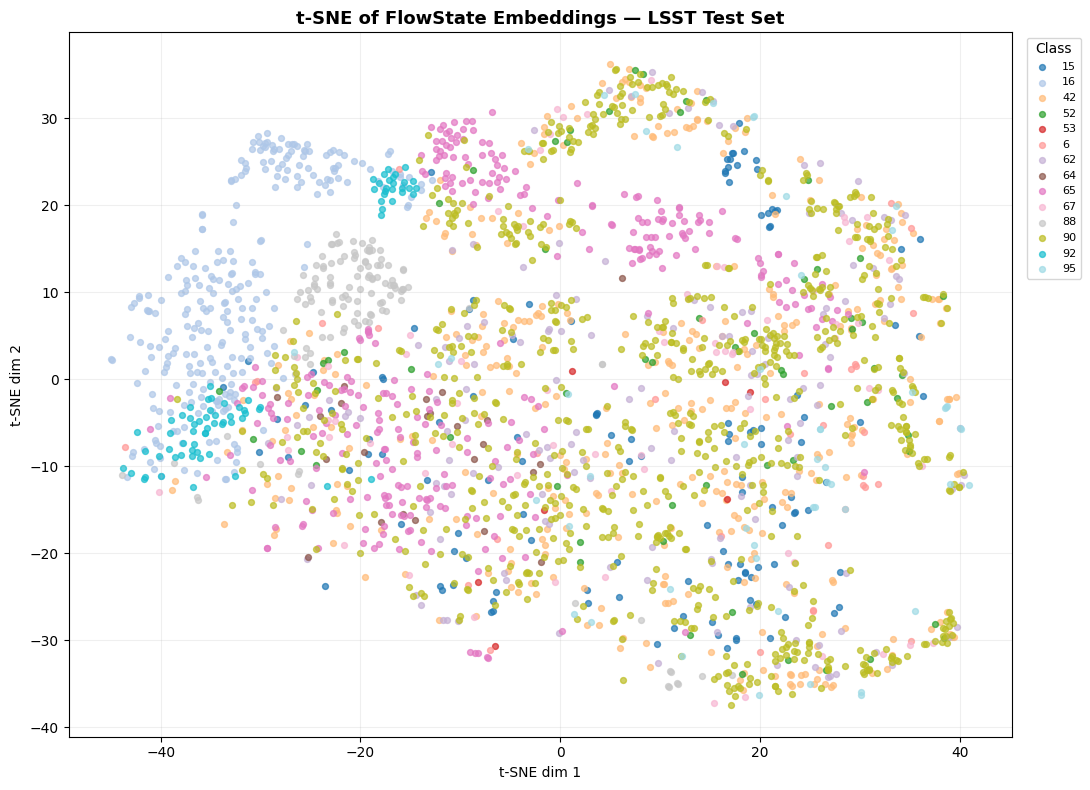

In [ ]:
## embeddings : mean, max, min
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
embs_2d = tsne.fit_transform(X_train_emb)

# Plot
fig, ax = plt.subplots(figsize=(11, 8))
cmap = plt.cm.get_cmap("tab20", N_CLASSES)

for cls_idx in range(N_CLASSES):
    mask = y_train_np == cls_idx
    ax.scatter(
        embs_2d[mask, 0], embs_2d[mask, 1],
        s=18, alpha=0.7, color=cmap(cls_idx),
        label=str(le.classes_[cls_idx])
    )

ax.legend(title="Class", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_title("t-SNE of Chronos Embeddings on LSST Test Set",
             fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7946/2770323571.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", N_CLASSES)


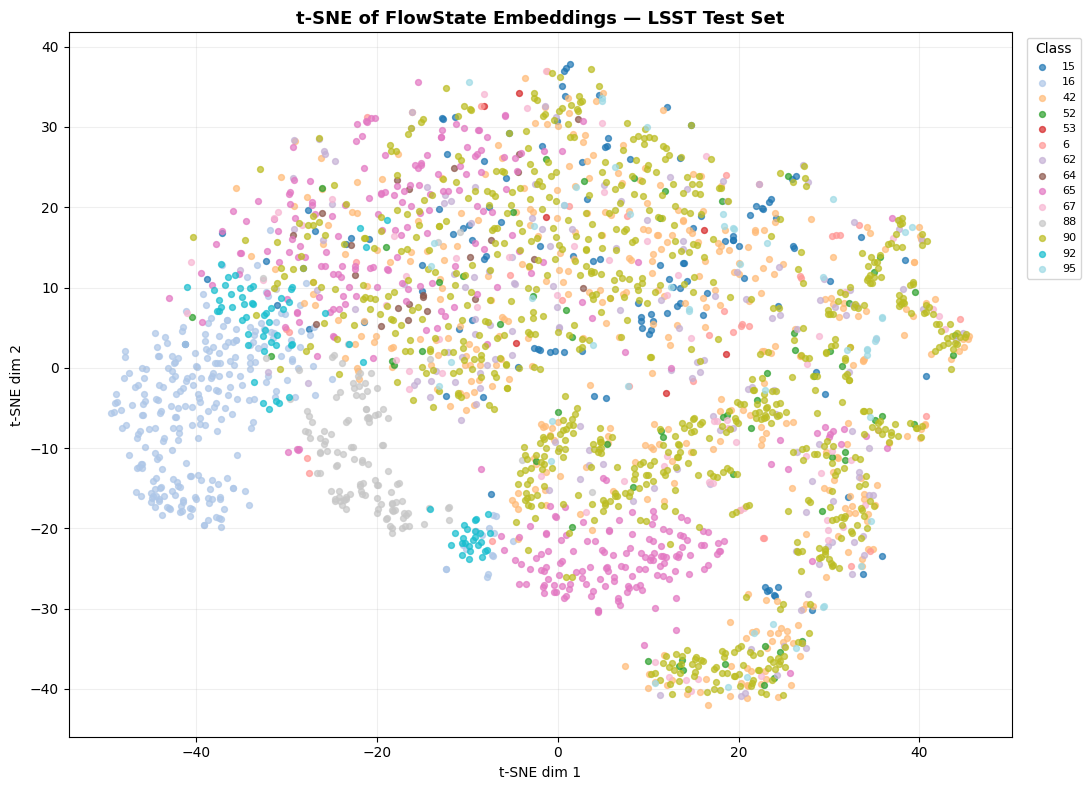

In [ ]:
## Embeddings : only REG token

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
embs_2d = tsne.fit_transform(X_train_emb)

# Plot
fig, ax = plt.subplots(figsize=(11, 8))
cmap = plt.cm.get_cmap("tab20", N_CLASSES)

for cls_idx in range(N_CLASSES):
    mask = y_train_np == cls_idx
    ax.scatter(
        embs_2d[mask, 0], embs_2d[mask, 1],
        s=18, alpha=0.7, color=cmap(cls_idx),
        label=str(le.classes_[cls_idx])
    )

ax.legend(title="Class", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_title("t-SNE of Chronos Embeddings on LSST Test Set",
             fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13535/2269453828.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", N_CLASSES)



Extracting mode: reg_mean_max
Extracting embeddings :

Extracting mode: observed_meanmax
Extracting embeddings :

Extracting mode: patch_reg_tokenwise_mean
Extracting embeddings :

Extracting mode: patch_reg_tokenwise_meanmax
Extracting embeddings :

Extracting mode: token_mean_flatten
Extracting embeddings :

Extracting mode: token_mean_channelmean
Extracting embeddings :


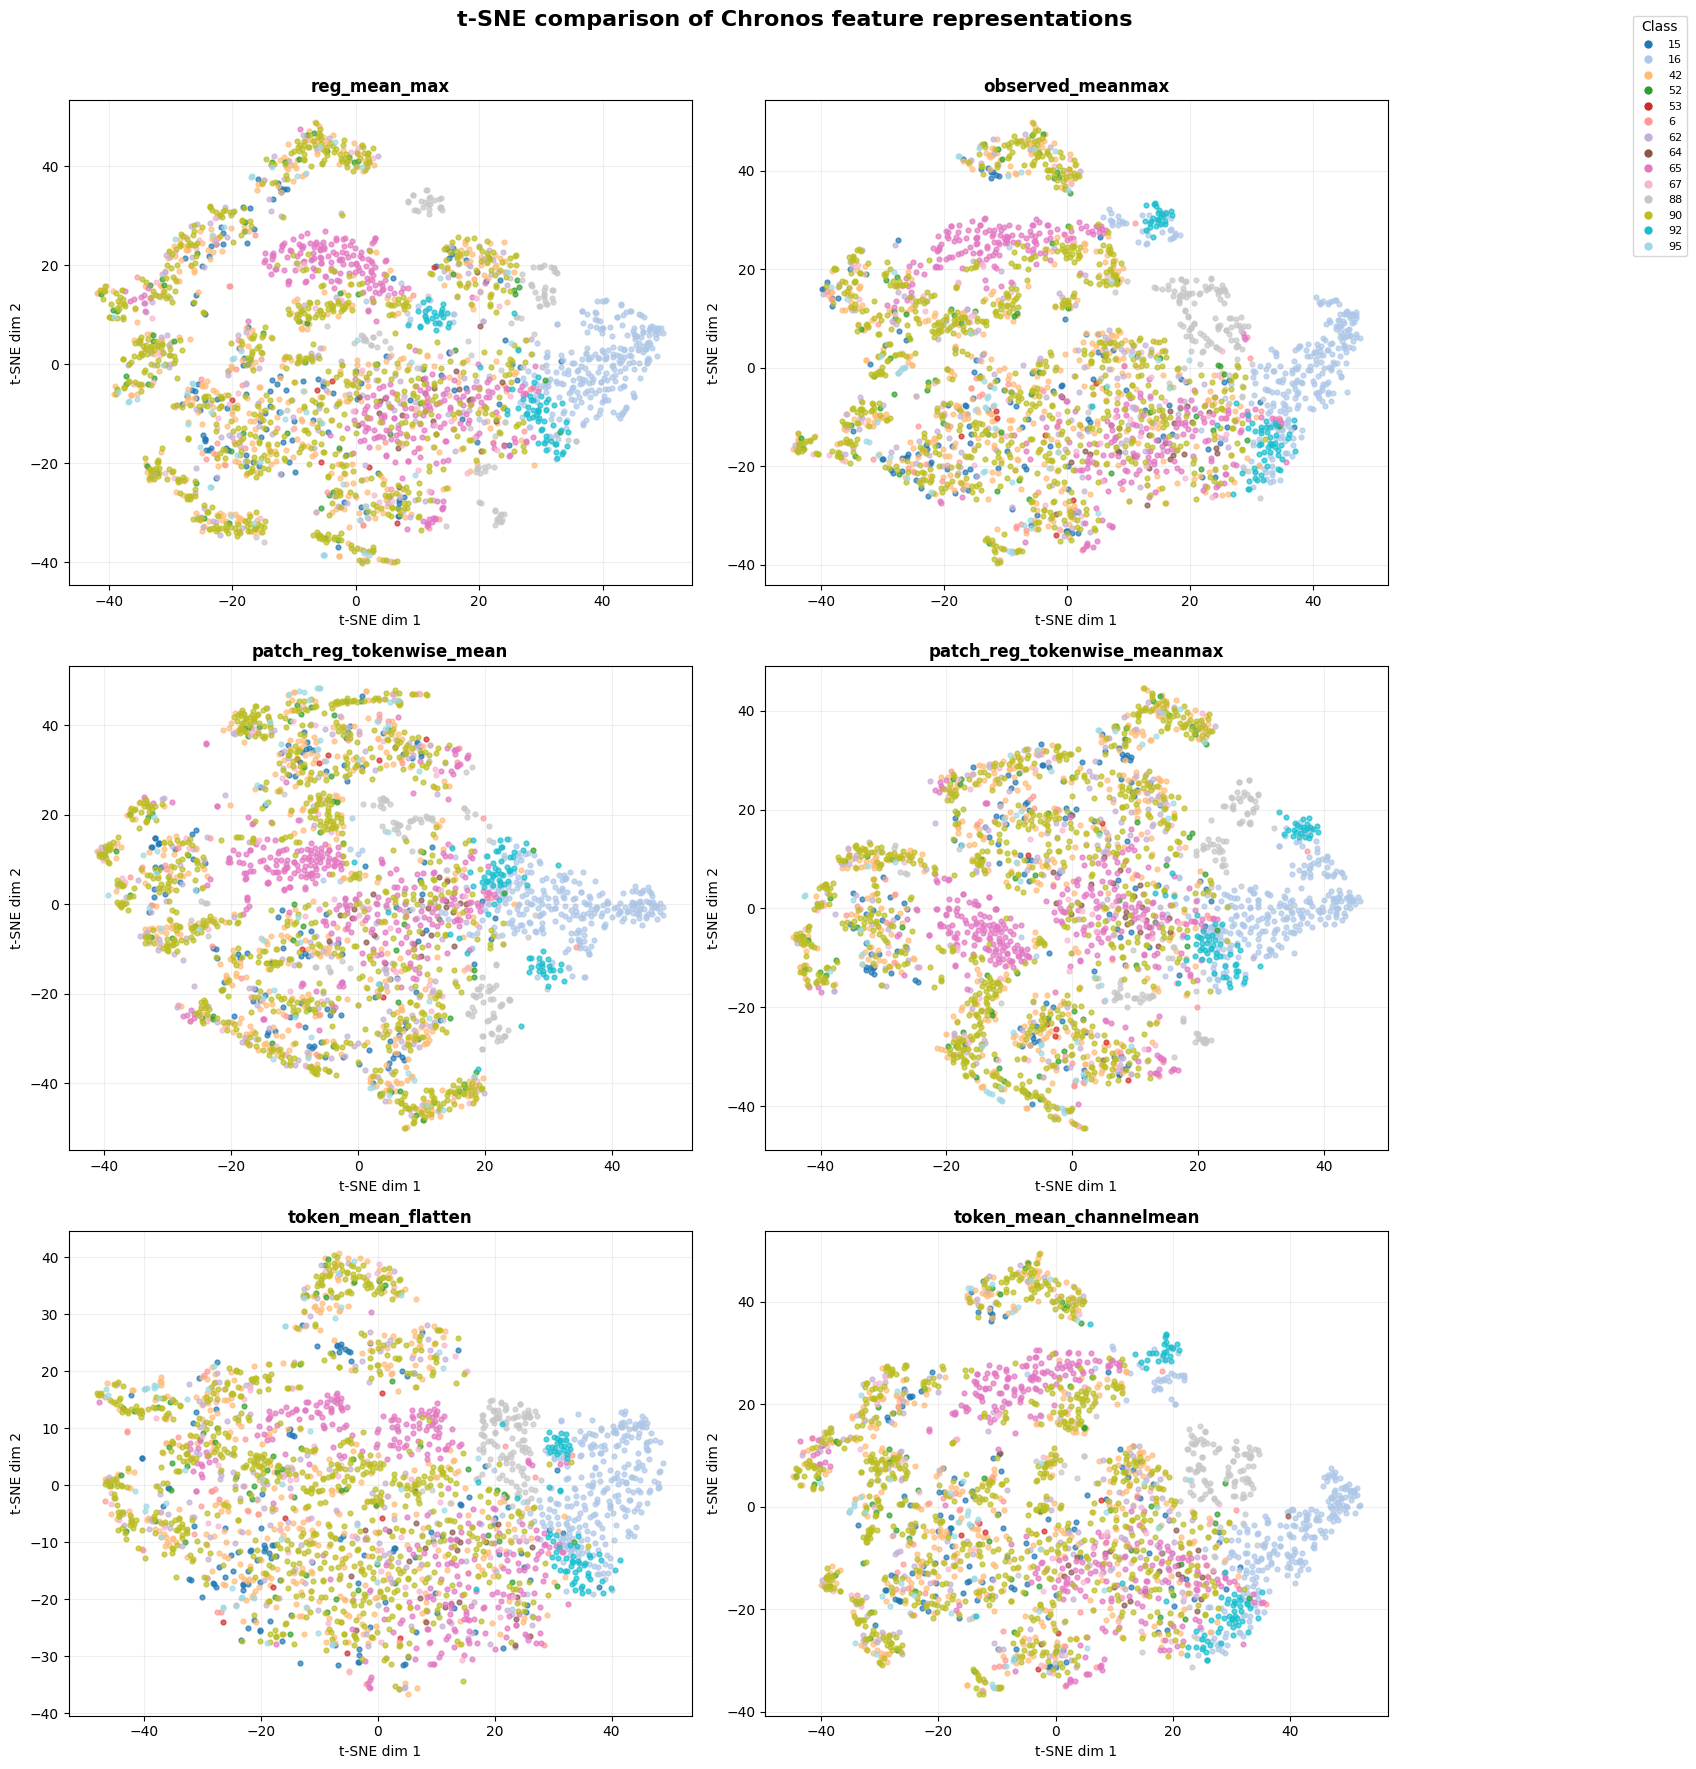

In [ ]:
## Embeddings : all at once (diff combin pooling)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_modes = [
    "reg_mean_max",
    "observed_meanmax",
    "patch_reg_tokenwise_mean",
    "patch_reg_tokenwise_meanmax",
    "token_mean_flatten",
    "token_mean_channelmean",
]

n_modes = len(feature_modes)
ncols = 2
nrows = math.ceil(n_modes / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows))
axes = np.array(axes).reshape(-1)

cmap = plt.cm.get_cmap("tab20", N_CLASSES)
all_train_embeddings = {}

for ax, mode in zip(axes, feature_modes):
    print(f"\nExtracting mode: {mode}")

    extractor = Chronos2FeatureExtractorREG(
        input_channels=N_CH,
        chronos_model_name="amazon/chronos-2",
        feature_mode=mode,
    ).to(device)

    extractor.eval()

    X_train_emb, y_train_np = get_all_embeddings(train_loader, extractor, device)
    all_train_embeddings[mode] = (X_train_emb, y_train_np)

    X_vis = StandardScaler().fit_transform(X_train_emb)

    tsne = TSNE(
        n_components=2,
        perplexity=40,
        random_state=42,
        max_iter=1000,
        init="pca",
        learning_rate="auto",
    )
    embs_2d = tsne.fit_transform(X_vis)

    for cls_idx in range(N_CLASSES):
        mask = y_train_np == cls_idx
        ax.scatter(
            embs_2d[mask, 0],
            embs_2d[mask, 1],
            s=12,
            alpha=0.7,
            color=cmap(cls_idx),
        )

    ax.set_title(mode, fontsize=12, fontweight="bold")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.grid(alpha=0.2)

for j in range(len(feature_modes), len(axes)):
    axes[j].axis("off")

handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=cmap(i),
        markersize=7,
        label=str(le.classes_[i]) if "le" in globals() else str(i)
    )
    for i in range(N_CLASSES)
]

fig.legend(
    handles=handles,
    title="Class",
    bbox_to_anchor=(1.02, 0.98),
    loc="upper left",
    fontsize=8
)

fig.suptitle("t-SNE comparison of Chronos feature representations", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.88, 0.97])
plt.show()

/tmp/ipykernel_13535/168862929.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", N_CLASSES)



Extracting mode: reg_flatten
Extracting embeddings :

Extracting mode: reg_mean
Extracting embeddings :

Extracting mode: reg_mean_max_std
Extracting embeddings :


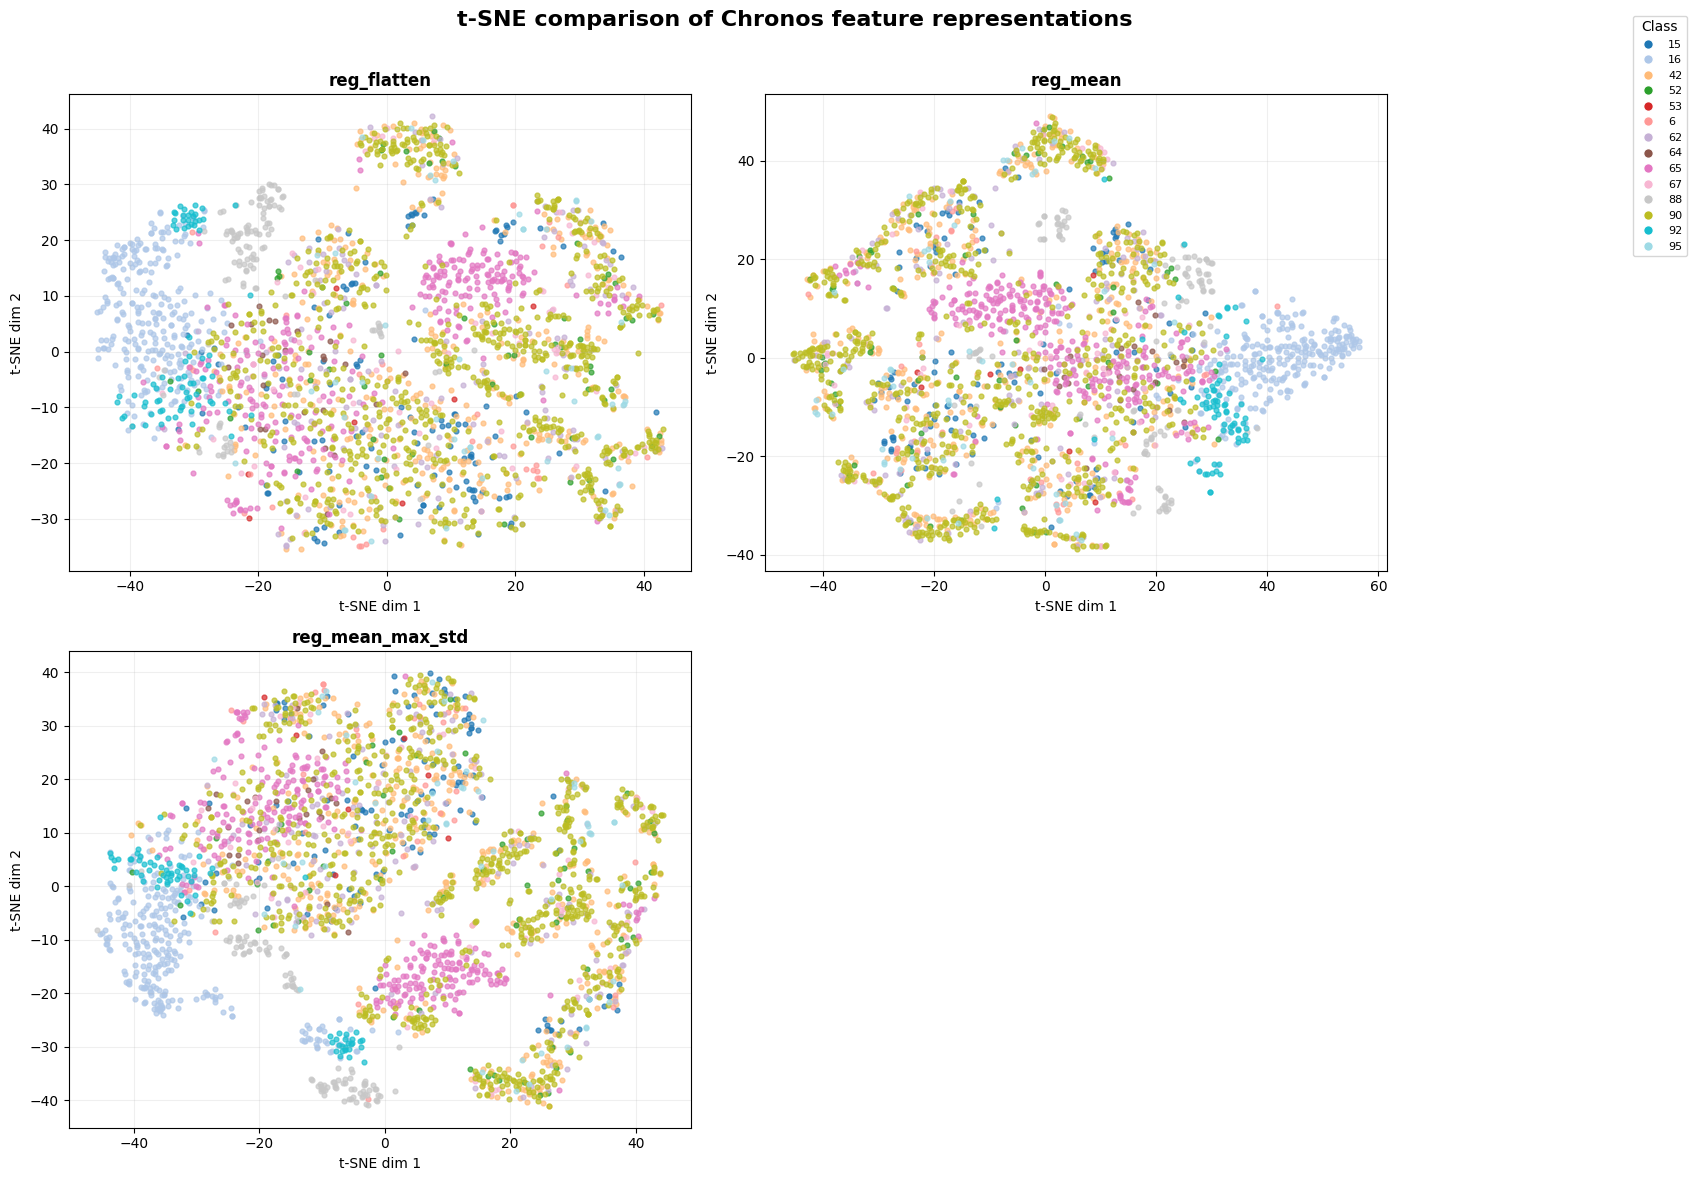

In [ ]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_modes = [
    "reg_flatten",
    "reg_mean",
    "reg_mean_max_std",
]

n_modes = len(feature_modes)
ncols = 2
nrows = math.ceil(n_modes / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows))
axes = np.array(axes).reshape(-1)

cmap = plt.cm.get_cmap("tab20", N_CLASSES)
all_train_embeddings = {}

for ax, mode in zip(axes, feature_modes):
    print(f"\nExtracting mode: {mode}")

    extractor = Chronos2FeatureExtractorREG(
        input_channels=N_CH,
        chronos_model_name="amazon/chronos-2",
        feature_mode=mode,
    ).to(device)

    extractor.eval()

    X_train_emb, y_train_np = get_all_embeddings(train_loader, extractor, device)
    all_train_embeddings[mode] = (X_train_emb, y_train_np)

    X_vis = StandardScaler().fit_transform(X_train_emb)

    tsne = TSNE(
        n_components=2,
        perplexity=40,
        random_state=42,
        max_iter=1000,
        init="pca",
        learning_rate="auto",
    )
    embs_2d = tsne.fit_transform(X_vis)

    for cls_idx in range(N_CLASSES):
        mask = y_train_np == cls_idx
        ax.scatter(
            embs_2d[mask, 0],
            embs_2d[mask, 1],
            s=12,
            alpha=0.7,
            color=cmap(cls_idx),
        )

    ax.set_title(mode, fontsize=12, fontweight="bold")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.grid(alpha=0.2)

for j in range(len(feature_modes), len(axes)):
    axes[j].axis("off")

handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=cmap(i),
        markersize=7,
        label=str(le.classes_[i]) if "le" in globals() else str(i)
    )
    for i in range(N_CLASSES)
]

fig.legend(
    handles=handles,
    title="Class",
    bbox_to_anchor=(1.02, 0.98),
    loc="upper left",
    fontsize=8
)

fig.suptitle("t-SNE comparison of Chronos feature representations", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.88, 0.97])
plt.show()

# Classic classif head

In [ ]:
import torch
import torch.nn as nn
from chronos import Chronos2Pipeline

class Chronos2EmbeddingClassifier(nn.Module):
    def __init__(
        self,
        n_classes: int,
        input_channels: int = 6,
        head_hidden_dim: int = 256,
        dropout: float = 0.2,
        chronos_model_name: str = "amazon/chronos-2",
    ):
        super().__init__()
        self.input_channels = input_channels

        chronos_device = "cuda" if torch.cuda.is_available() else "cpu"
        chronos_dtype = torch.bfloat16 if chronos_device == "cuda" else torch.float32

        self.pipeline = Chronos2Pipeline.from_pretrained(
            chronos_model_name,
            device_map=chronos_device,
            torch_dtype=chronos_dtype,
        )

        for param in self.pipeline.model.parameters():
            param.requires_grad = False

        embedding_dim = self.pipeline.model.config.d_model

        pooled_feature_dim = input_channels * 3 * embedding_dim

        self.feature_dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
          nn.Linear(pooled_feature_dim, 1024),
          nn.BatchNorm1d(1024),
          nn.GELU(),
          nn.Dropout(dropout),

          nn.Linear(1024, head_hidden_dim),
          nn.BatchNorm1d(head_hidden_dim),
          nn.GELU(),
          nn.Dropout(dropout),

          nn.Linear(head_hidden_dim, n_classes),
      )

    @torch.no_grad()
    def extract_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 3:
            raise ValueError(f"Expected (batch, timesteps, channels), got {tuple(x.shape)}")

        x_permuted = x.permute(0, 2, 1).contiguous()

        chronos_inputs = [sample.cpu() for sample in x_permuted]

        embeddings, _ = self.pipeline.embed(chronos_inputs)

        pooled_features = []
        for sample_embedding in embeddings:
            token_mean = sample_embedding.mean(dim=1)
            token_max = sample_embedding.max(dim=1).values
            token_min = sample_embedding.min(dim=1).values

            pooled = torch.cat([token_mean, token_max, token_min], dim=-1).reshape(-1)
            pooled_features.append(pooled)

        return torch.stack(pooled_features, dim=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.extract_embeddings(x).to(device=x.device, dtype=torch.float32)
        features = self.feature_dropout(features)
        return self.classifier(features)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Chronos2EmbeddingClassifier(
    n_classes=N_CLASSES,
    input_channels=N_CH,
    head_hidden_dim=256,
    dropout=0.3,
    chronos_model_name="amazon/chronos-2",
).to(device)

xb, yb = next(iter(train_loader))
with torch.no_grad():
    sample_features = model.extract_embeddings(xb)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Chronos-2 pooled feature shape : {sample_features.shape}")
print(f"Trainable head params          : {trainable_params:,}")

Chronos-2 pooled feature shape : torch.Size([512, 13824])
Trainable head params          : 14,425,358


In [ ]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    y_train=y_train,
    device=device,
    n_epochs=20,
    lr=1e-3,
    weight_decay=1e-4,
    patience=10,
    label="Chronos2_embedding_classifier"
)
results_chronos2 = test_model(
    model=model,
    test_loader=test_loader,
    y_train=y_train,
    device=device
)


Training: Chronos2_embedding_classifier
Epoch |   TrLoss |   TrAcc |    TrF1 |   VaLoss |   VaAcc |    VaF1
------------------------------------------------------------------------
    1 |   2.6210 | 22.81% | 0.2063 |   2.8467 | 18.37% | 0.1353  <- best
    2 |   2.0117 | 35.79% | 0.3425 |   2.6665 | 30.62% | 0.2676  <- best
    3 |   1.7201 | 41.20% | 0.4126 |   2.5808 | 36.01% | 0.3231  <- best
    4 |   1.5407 | 48.47% | 0.4913 |   2.4039 | 41.93% | 0.3861  <- best
    5 |   1.3748 | 54.58% | 0.5523 |   2.3552 | 43.84% | 0.3955  <- best
    6 |   1.2662 | 61.85% | 0.6138 |   2.3972 | 44.24% | 0.4030  <- best
    7 |   1.1816 | 66.61% | 0.6705 |   2.3811 | 43.07% | 0.3850
    8 |   1.1233 | 72.02% | 0.7123 |   2.4349 | 43.11% | 0.3738
    9 |   1.0841 | 77.10% | 0.7579 |   2.4124 | 44.36% | 0.4004
   10 |   1.0423 | 80.15% | 0.7923 |   2.3189 | 52.11% | 0.4295  <- best
   11 |   1.0191 | 80.81% | 0.7943 |   2.3169 | 53.28% | 0.4349  <- best
   12 |   1.0046 | 83.86% | 0.8187 |   2.3

# Baseline

In [ ]:
import copy
import time
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn


def train_one_epoch(model, loader, optimizer, criterion, device, max_grad_norm=1.0):
    model.train()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for xb, yb in loader:
        xb = xb.to(device).float()
        yb = yb.to(device).long()

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.detach().cpu())
        all_targets.append(yb.detach().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for xb, yb in loader:
        xb = xb.to(device).float()
        yb = yb.to(device).long()

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_targets.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")
    report = classification_report(all_targets, all_preds, digits=4)

    return avg_loss, acc, f1, all_preds, all_targets, report

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    y_train,
    device,
    n_epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    patience=8,
    label="model",
):
    classes = np.unique(y_train)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(
        weight=weights_tensor
    )

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_f1": []
    }

    best_f1 = -1.0
    best_state = copy.deepcopy(model.state_dict())
    patience_count = 0

    print(f"\n{'='*72}")
    print(f"Training: {label}")
    print(f"{'='*72}")
    print(f"{'Epoch':>5} | {'TrLoss':>8} | {'TrAcc':>7} | {'TrF1':>7} | {'VaLoss':>8} | {'VaAcc':>7} | {'VaF1':>7}")
    print(f"{'-'*72}")

    t0 = time.time()

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        va_loss, va_acc, va_f1, _, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step(va_f1)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["train_f1"].append(tr_f1)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["val_f1"].append(va_f1)

        print(
            f"{epoch:>5} | {tr_loss:>8.4f} | {tr_acc:>6.2%} | {tr_f1:>6.4f} | "
            f"{va_loss:>8.4f} | {va_acc:>6.2%} | {va_f1:>6.4f}",
            end=""
        )

        if va_f1 > best_f1:
            best_f1 = va_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0
            print("  <- best", end="")
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\nEarly stopping at epoch {epoch}.")
                break

        print()

    elapsed = time.time() - t0
    print(f"\nDone | Best val macro-F1 = {best_f1:.4f} | Time = {elapsed:.1f}s")

    model.load_state_dict(best_state)
    return model, history

In [ ]:
def test_model(model, test_loader, y_train, device):
    classes = np.unique(y_train)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(
        weight=weights_tensor
    )

    te_loss, te_acc, te_f1, preds, targets, report = evaluate(
        model, test_loader, criterion, device
    )

    print("\nTest results")
    print(f"Loss     : {te_loss:.4f}")
    print(f"Accuracy : {te_acc:.4%}")
    print(f"Macro-F1 : {te_f1:.4f}")
    print("\nClassification report:\n")
    print(report)

    return {
        "test_loss": te_loss,
        "test_acc": te_acc,
        "test_f1": te_f1,
        "preds": preds,
        "targets": targets,
        "report": report,
    }

In [ ]:
class CNN1DClassifier(nn.Module):

    def __init__(self, n_channels: int, n_steps: int, n_classes: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.GELU(),
            nn.AdaptiveAvgPool1d(8),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.head(self.conv(x.permute(0, 2, 1)))


In [ ]:
model_cnn = CNN1DClassifier(N_CH, N_STEPS, N_CLASSES).to(device)
total_cnn = sum(p.numel() for p in model_cnn.parameters())
print(f"CNN baseline params : {total_cnn:,}")

model_cnn, history_cnn = train_model(
    model=model_cnn,
    train_loader=train_loader,
    val_loader=test_loader,
    y_train=y_train,
    device=device,
    n_epochs=50,
    lr=1e-3,
    patience=12,
    label="1D_CNN"
)

In [ ]:
results_cnn = test_model(
    model=model_cnn,
    test_loader=test_loader,
    y_train=y_train,
    device=device
)